# Lab 01 — Introduction to CV & Basic Image Operations (AI-4002)
**Topics:** reading/displaying images, BGR→RGB, grayscale, resize, blur, cropping (ROI), text, drawing, Pandas analysis, thresholding, rotation, blending, histogram equalization, bitwise masking.

| Section | What's inside |
|---|---|
| 0 | Setup — creates sample images in `data/` (replace with your own) |
| A | Manual operations 11.1 – 11.12 (quick reference code) |
| B | Lab tasks: Part 1 (setup) · Task 1 Grocery · Task 2 Students · Task 3 Load/RGB · Task 4 Canvas · Task 5 Blur+ROI · Task 6 Blending · Task 7 Threshold+Rotation · Task 8 Masking · Task 9 Pandas |

## 0. Setup — sample images (skip if you have your own)

In [1]:
import os, cv2, numpy as np
from skimage import data          # only used to create sample images
os.makedirs('data', exist_ok=True)
if not os.path.exists('data/Sukuna.jpeg'):
    cv2.imwrite('data/Sukuna.jpeg', cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR))
if not os.path.exists('data/Gojo.jpeg'):
    cv2.imwrite('data/Gojo.jpeg', cv2.cvtColor(data.chelsea(), cv2.COLOR_RGB2BGR))
if not os.path.exists('data/doc.jpg'):
    cv2.imwrite('data/doc.jpg', data.page())          # unevenly-lit document
print(os.listdir('data'))

['Sukuna.jpeg', 'Gojo.jpeg', 'doc.jpg']


## A. Manual operations (11.1 – 11.12) — quick reference
Each cell = one operation from the manual. Copy the one you need.

shape (h, w, c): (512, 512, 3) | gray: (512, 512)


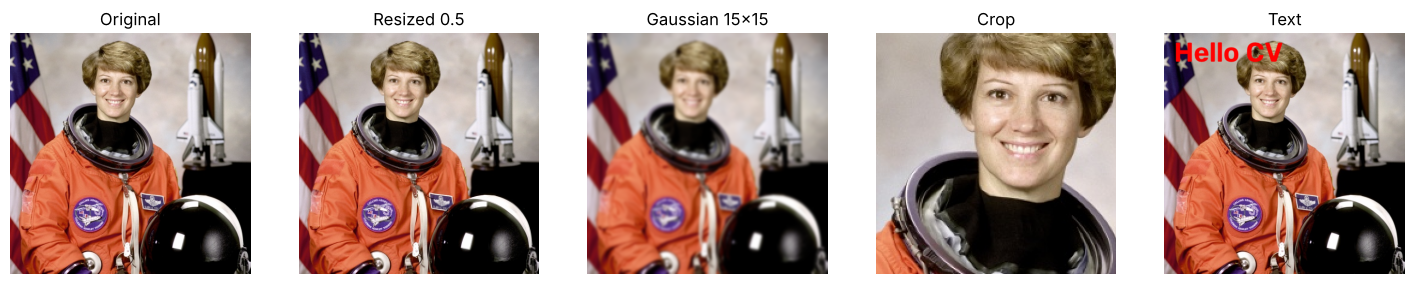

In [2]:
import cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt

img = cv2.imread('data/Sukuna.jpeg')                 # 11.1 read  (BGR!)
if img is None: raise FileNotFoundError('check path')
rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)          # for matplotlib
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)         # 11.2 grayscale -> shape (h, w)
h, w = img.shape[:2]
print('shape (h, w, c):', img.shape, '| gray:', gray.shape)

resized  = cv2.resize(rgb, (w // 2, h // 2))         # 11.4 resize: dsize = (WIDTH, HEIGHT)
resized2 = cv2.resize(rgb, None, fx=0.5, fy=0.5)     #      or by scale factors
blur     = cv2.GaussianBlur(rgb, (15, 15), 0)        # 11.5 blur: kernel odd, sigma 0 = auto
crop     = rgb[50:250, 100:300]                      # 11.6 crop: [y1:y2, x1:x2]
txt      = rgb.copy()
cv2.putText(txt, 'Hello CV', (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 0, 0), 3)  # 11.7 (x,y)=bottom-left of text

fig, ax = plt.subplots(1, 5, figsize=(18, 4))
for a, im, t in zip(ax, [rgb, resized, blur, crop, txt], ['Original', 'Resized 0.5', 'Gaussian 15x15', 'Crop', 'Text']):
    a.imshow(im); a.set_title(t); a.axis('off')
plt.show()

In [3]:
# 11.8 Analyze the image using Pandas (pixels as rows, channels as columns)
df = pd.DataFrame(img.reshape(-1, 3), columns=['Blue', 'Green', 'Red'])   # still BGR order!
print(df.describe().loc[['mean', 'std', 'min', 'max']])

            Blue       Green         Red
mean   96.454277  105.792023  141.547424
std    77.545758   76.504404   82.062659
min     0.000000    0.000000    0.000000
max   255.000000  255.000000  255.000000


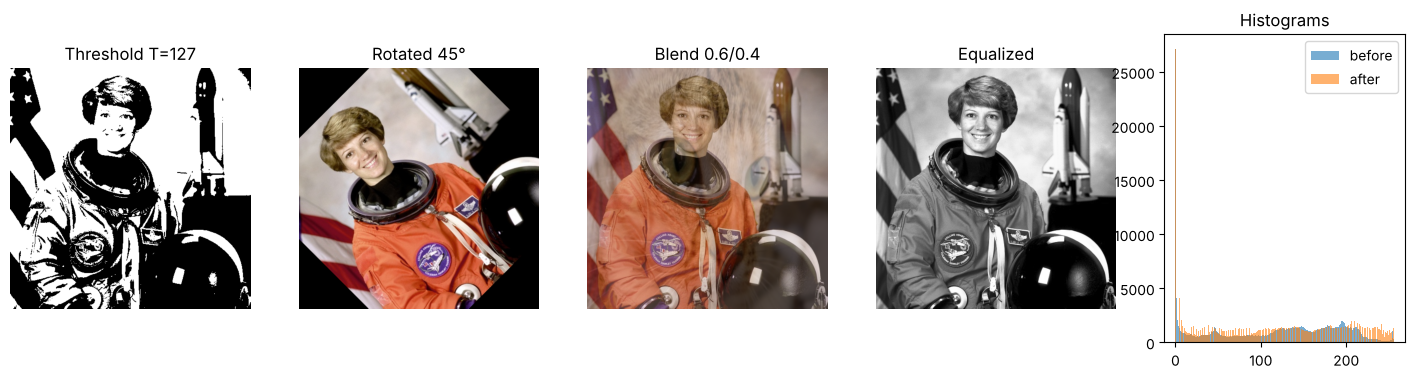

In [4]:
# 11.9 Thresholding  | 11.10 Rotation | 11.11 Blending | 11.12 Histogram Equalization
ret, th = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)       # pixel > 127 -> 255 else 0
M  = cv2.getRotationMatrix2D((w / 2, h / 2), 45, 1.0)            # +angle = counter-clockwise, 2x3 matrix
rot = cv2.warpAffine(rgb, M, (w, h))                             # dsize = (w, h)
img2 = cv2.resize(cv2.cvtColor(cv2.imread('data/Gojo.jpeg'), cv2.COLOR_BGR2RGB), (w, h))  # same size needed
blend = cv2.addWeighted(rgb, 0.6, img2, 0.4, 0)                  # rgb*0.6 + img2*0.4 + 0
eq = cv2.equalizeHist(gray)                                      # grayscale 8-bit only

fig, ax = plt.subplots(1, 5, figsize=(18, 4))
ax[0].imshow(th, cmap='gray'); ax[0].set_title(f'Threshold T={ret:.0f}')
ax[1].imshow(rot); ax[1].set_title('Rotated 45°')
ax[2].imshow(blend); ax[2].set_title('Blend 0.6/0.4')
ax[3].imshow(eq, cmap='gray'); ax[3].set_title('Equalized')
ax[4].hist(gray.ravel(), bins=256, range=(0, 256), alpha=.6, label='before'); ax[4].hist(eq.ravel(), bins=256, range=(0, 256), alpha=.6, label='after'); ax[4].legend(); ax[4].set_title('Histograms')
for a in ax[:4]: a.axis('off')
plt.show()

# B. Lab 01 Tasks

## Part 1 — Environment Setup & Validation
### 1.1 Installation

In [5]:
# Run once if libraries are missing:
# %pip install opencv-python matplotlib pandas numpy

### 1.2 Import & Validate

In [6]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("OpenCV version :", cv2.__version__)
print("NumPy version  :", np.__version__)

# Quick functional test: make a tiny image and run one OpenCV call on it
test = np.zeros((10, 10, 3), dtype=np.uint8)
gray_test = cv2.cvtColor(test, cv2.COLOR_BGR2GRAY)
assert gray_test.shape == (10, 10), "OpenCV conversion failed"

fig = plt.figure(figsize=(1, 1)); plt.close(fig)   # Matplotlib can create figures
print("All libraries are working ✅")

# Paths used throughout the notebook
image_path  = 'data/Sukuna.jpeg'
image2_path = 'data/Gojo.jpeg'
doc_path    = 'data/doc.jpg'

OpenCV version : 5.0.0
NumPy version  : 2.5.3
All libraries are working ✅


## Part 2 — Python Data Structures & Logic
### Task 1: Object-Oriented Grocery Manager

In [7]:
class GroceryManager:
    def __init__(self):
        # item name -> {'quantity': int, 'price': float (per unit)}
        self.items = {}

    def add_item(self, item, quantity, price):
        if quantity <= 0 or price < 0:
            print("Error: quantity must be > 0 and price must be >= 0.")
            return
        if item in self.items:                      # already in list -> increase quantity
            self.items[item]['quantity'] += quantity
            self.items[item]['price'] = price
        else:
            self.items[item] = {'quantity': quantity, 'price': price}
        print(f"Added {quantity} x {item} @ {price:.2f}")

    def remove_item(self, item):
        try:
            del self.items[item]
            print(f"Removed '{item}'.")
        except KeyError:                            # error handling: item doesn't exist
            print(f"Error: '{item}' is not in the grocery list.")

    def view_list(self):
        if not self.items:
            print("The grocery list is empty.")
            return
        print(f"{'Item':<12}{'Qty':>5}{'Price':>10}{'Subtotal':>12}")
        for name, d in self.items.items():
            print(f"{name:<12}{d['quantity']:>5}{d['price']:>10.2f}{d['quantity']*d['price']:>12.2f}")

    def calculate_total(self):
        return sum(d['quantity'] * d['price'] for d in self.items.values())


gm = GroceryManager()
gm.add_item('Milk', 2, 250)
gm.add_item('Eggs', 12, 30)
gm.add_item('Bread', 1, 180)
gm.view_list()
print("Total:", gm.calculate_total())
gm.remove_item('Butter')      # does not exist -> error message
gm.remove_item('Bread')
gm.view_list()
print("Total:", gm.calculate_total())

Added 2 x Milk @ 250.00
Added 12 x Eggs @ 30.00
Added 1 x Bread @ 180.00
Item          Qty     Price    Subtotal
Milk            2    250.00      500.00
Eggs           12     30.00      360.00
Bread           1    180.00      180.00
Total: 1040
Error: 'Butter' is not in the grocery list.
Removed 'Bread'.
Item          Qty     Price    Subtotal
Milk            2    250.00      500.00
Eggs           12     30.00      360.00
Total: 860


### Task 2: Advanced Student Record System

In [8]:
students = {
    101: {'Name': 'Ayesha', 'Major': 'AI', 'Grades': [88, 92, 79]},
    102: {'Name': 'Bilal',  'Major': 'CS', 'Grades': [75, 81, 90]},
    103: {'Name': 'Sara',   'Major': 'AI', 'Grades': [95, 89, 93]},
    104: {'Name': 'Hamza',  'Major': 'SE', 'Grades': [60, 72, 68]},
}

def average(grades):
    return sum(grades) / len(grades) if grades else 0

def top_student(records):
    if not records:
        return None
    best_id = max(records, key=lambda sid: average(records[sid]['Grades']))
    return records[best_id]['Name']

def search_by_major(records, major):
    found = False
    print(f"Students in {major}:")
    for sid, info in records.items():
        if info['Major'].lower() == major.lower():
            print(f"  ID {sid}: {info['Name']} (avg {average(info['Grades']):.2f})")
            found = True
    if not found:
        print("  No students found.")

print("Highest average:", top_student(students))
search_by_major(students, 'AI')
search_by_major(students, 'EE')

Highest average: Sara
Students in AI:
  ID 101: Ayesha (avg 86.33)
  ID 103: Sara (avg 92.33)
Students in EE:
  No students found.


## Part 3 — Core Computer Vision & Matplotlib
### Task 3: Safe Image Loading & RGB Visualization

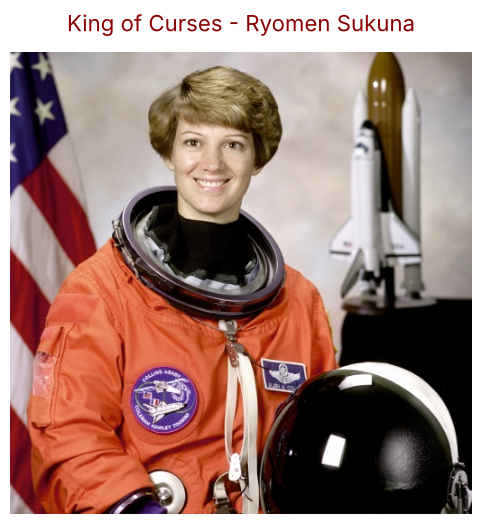

In [9]:
image = cv2.imread(image_path)

if image is None:                                   # cv2.imread does NOT raise an error; it returns None
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.axis('off')
    plt.title('King of Curses - Ryomen Sukuna', fontsize=16, color='darkred', pad=15)
    plt.imshow(image_rgb)
    plt.show()

### Task 4: Interactive Geometry & Blank Canvas

Canvas center (x, y): (400, 400)
Bounding box: (100, 100) -> (700, 700)


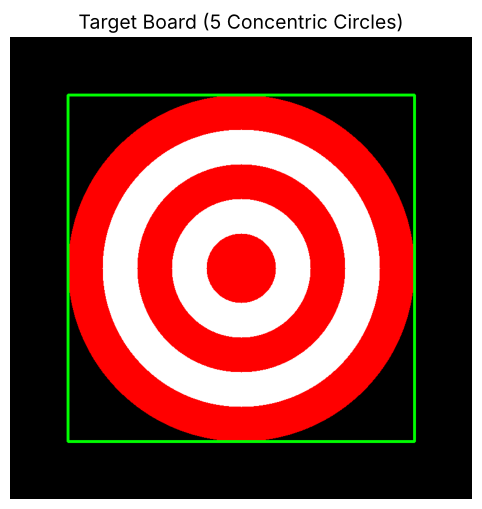

In [10]:
canvas = np.zeros((800, 800, 3), dtype=np.uint8)    # black canvas: (height, width, channels)
h, w = canvas.shape[:2]
center = (w // 2, h // 2)                            # OpenCV points are (x, y)

# Colours written as RGB because we display with Matplotlib without converting
colors = [(255, 0, 0), (255, 255, 255)]              # red, white (alternating)
radii  = [300, 240, 180, 120, 60]                    # biggest first so smaller ones draw on top

for i, r in enumerate(radii):
    cv2.circle(canvas, center, r, colors[i % 2], -1) # thickness -1 = filled

outer = radii[0]
top_left     = (center[0] - outer, center[1] - outer)
bottom_right = (center[0] + outer, center[1] + outer)
cv2.rectangle(canvas, top_left, bottom_right, (0, 255, 0), 3)

print("Canvas center (x, y):", center)
print("Bounding box:", top_left, "->", bottom_right)

plt.figure(figsize=(6, 6))
plt.imshow(canvas)
plt.title('Target Board (5 Concentric Circles)', fontsize=14)
plt.axis('off')
plt.show()

### Task 5: Advanced Blurring & NumPy ROI Extraction

ROI shape: (300, 300, 3)


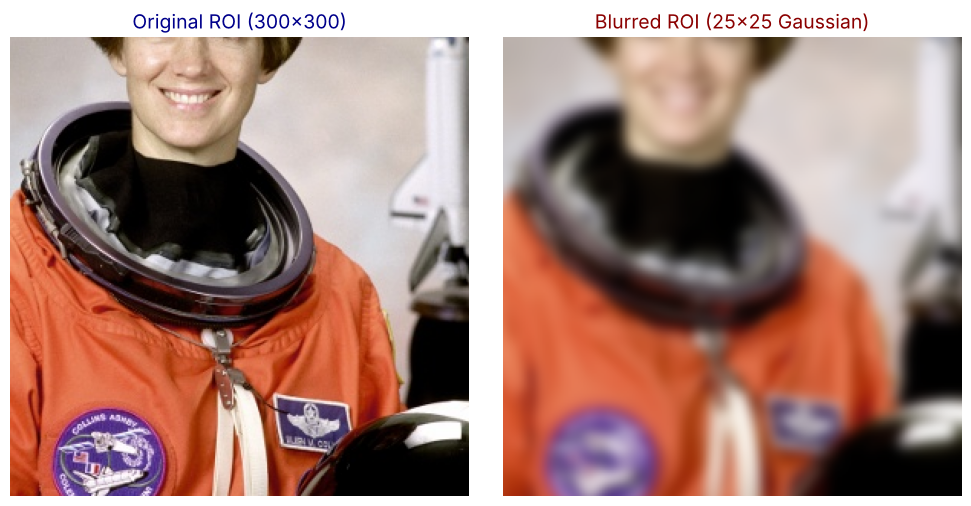

In [11]:
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    blurred = cv2.GaussianBlur(image_rgb, (25, 25), 0)   # kernel must be odd; sigma 0 = auto

    h, w = image_rgb.shape[:2]
    cy, cx = h // 2, w // 2
    half = 150                                            # 300 / 2

    # NumPy slicing is [rows (y), cols (x)]
    roi_original = image_rgb[cy - half:cy + half, cx - half:cx + half]
    roi_blurred  = blurred[cy - half:cy + half, cx - half:cx + half]
    print("ROI shape:", roi_original.shape)               # (300, 300, 3)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(roi_original)
    axes[0].set_title('Original ROI (300x300)', fontsize=14, color='darkblue')
    axes[0].axis('off')
    axes[1].imshow(roi_blurred)
    axes[1].set_title('Blurred ROI (25x25 Gaussian)', fontsize=14, color='darkred')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

### Task 6: Alpha Blending & Typography

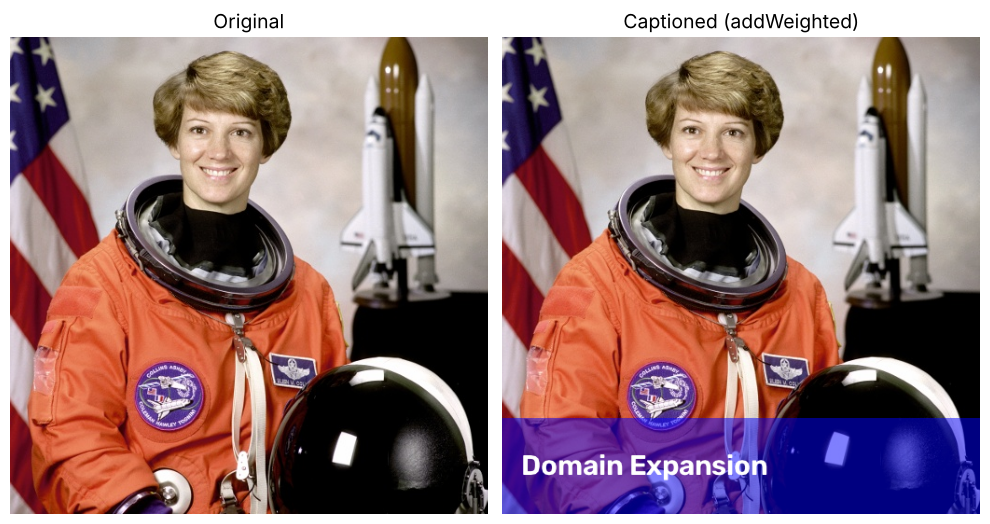

In [12]:
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image_rgb.shape[:2]

    overlay = image_rgb.copy()
    y0 = int(h * 0.8)                                     # bottom 20% starts here
    cv2.rectangle(overlay, (0, y0), (w, h), (0, 0, 255), -1)   # blue (RGB), filled

    alpha = 0.5
    captioned = cv2.addWeighted(overlay, alpha, image_rgb, 1 - alpha, 0)
    # result = overlay*alpha + image*(1-alpha) + 0

    font_scale = max(1.0, w / 500)                        # scale text with image size
    thickness  = max(2, w // 300)
    text_y = y0 + (h - y0) // 2 + int(10 * font_scale)    # roughly vertically centred in the box
    cv2.putText(captioned, 'Domain Expansion', (20, text_y),
                cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), thickness)

    fig, axes = plt.subplots(1, 2, figsize=(10, 6))
    axes[0].imshow(image_rgb); axes[0].set_title('Original', fontsize=14); axes[0].axis('off')
    axes[1].imshow(captioned); axes[1].set_title('Captioned (addWeighted)', fontsize=14); axes[1].axis('off')
    plt.tight_layout()
    plt.show()

### Task 7: Matrix-Based Rotation & Adaptive Thresholding

Rotation matrix (2x3):
 [[  0.56568542   0.56568542  29.36544033]
 [ -0.56568542   0.56568542 150.08864351]]


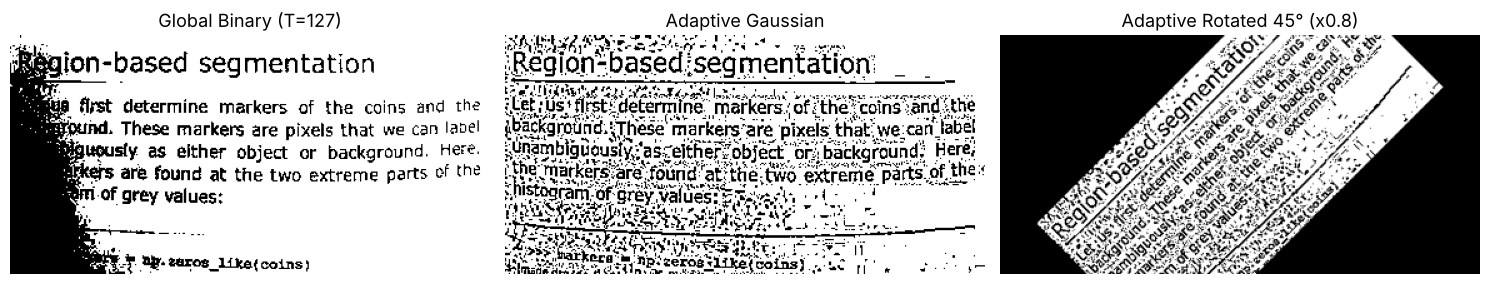

In [13]:
gray = cv2.imread(doc_path, cv2.IMREAD_GRAYSCALE)

if gray is None:
    print("Error: Image not found.")
else:
    # Global: one threshold (127) for the whole image
    ret, global_th = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    # Adaptive: threshold computed per neighbourhood (11x11 block, minus C=2)
    adaptive_th = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 11, 2)

    h, w = adaptive_th.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), 45, 0.8)   # center, angle (+ = CCW), scale
    print("Rotation matrix (2x3):\n", M)
    rotated = cv2.warpAffine(adaptive_th, M, (w, h))         # dsize is (width, height)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, img, t in zip(axes, [global_th, adaptive_th, rotated],
                          ['Global Binary (T=127)', 'Adaptive Gaussian', 'Adaptive Rotated 45° (x0.8)']):
        ax.imshow(img, cmap='gray'); ax.set_title(t, fontsize=13); ax.axis('off')
    plt.tight_layout()
    plt.show()

### Task 8: Masking with Bitwise Logic

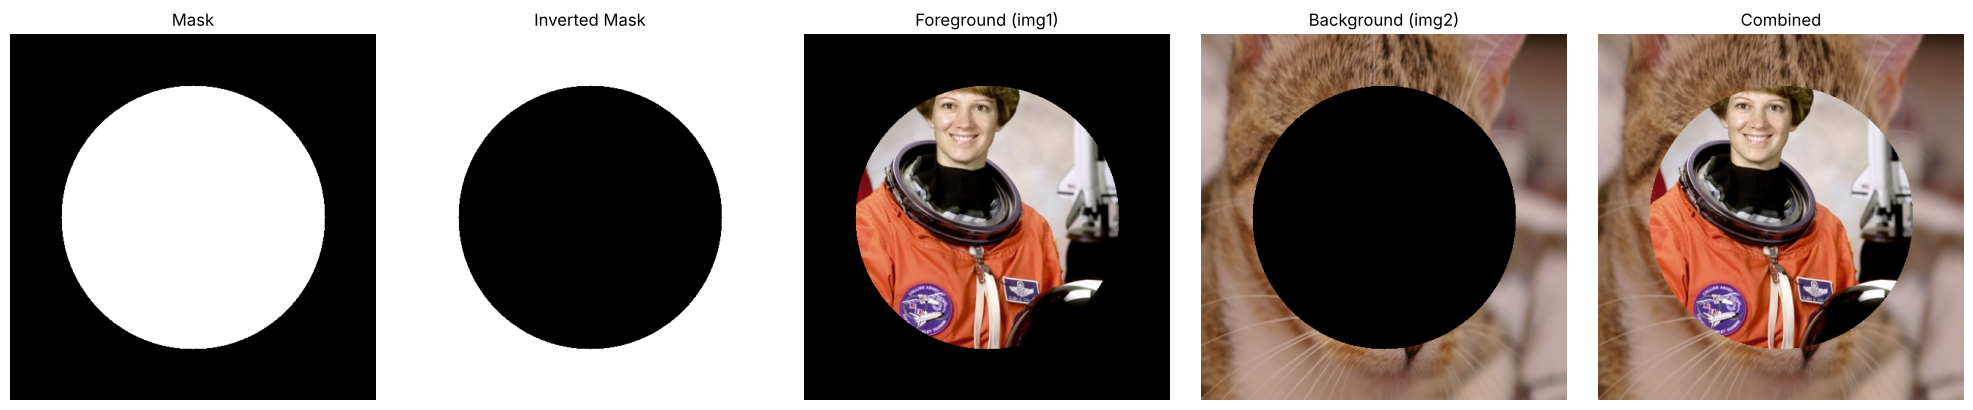

In [14]:
img1 = cv2.imread(image_path)
img2 = cv2.imread(image2_path)

if img1 is None or img2 is None:
    print("Error: One or both images not found.")
else:
    size = (500, 500)                                    # (width, height)
    img1 = cv2.resize(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB), size)
    img2 = cv2.resize(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB), size)

    mask = np.zeros((500, 500), dtype=np.uint8)          # mask must be single-channel uint8
    cv2.circle(mask, (250, 250), 180, 255, -1)           # white filled circle in the centre

    foreground = cv2.bitwise_and(img1, img1, mask=mask)  # keep circle from image 1
    mask_inv   = cv2.bitwise_not(mask)                   # invert: circle black, background white
    background = cv2.bitwise_and(img2, img2, mask=mask_inv)  # keep background from image 2
    combined   = cv2.bitwise_or(foreground, background)

    titles = ['Mask', 'Inverted Mask', 'Foreground (img1)', 'Background (img2)', 'Combined']
    images = [mask, mask_inv, foreground, background, combined]
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for ax, img, t in zip(axes, images, titles):
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(t, fontsize=12); ax.axis('off')
    plt.tight_layout()
    plt.show()

### Task 9: Statistical Image Profiling with Pandas

In [15]:
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)   # convert first so channel 0 really is Red

    red   = image_rgb[:, :, 0].flatten()                  # 2D -> 1D
    green = image_rgb[:, :, 1].flatten()
    blue  = image_rgb[:, :, 2].flatten()

    df = pd.DataFrame({'Red': red, 'Green': green, 'Blue': blue})
    print("Total pixels:", len(df))
    print(df.describe())
    print("\nKey stats:")
    print(df.describe().loc[['mean', 'std', 'min', 'max']])

Total pixels: 262144
                 Red          Green           Blue
count  262144.000000  262144.000000  262144.000000
mean      141.547424     105.792023      96.454277
std        82.062659      76.504404      77.545758
min         0.000000       0.000000       0.000000
25%        74.000000      25.000000      20.000000
50%       174.000000     108.000000      82.000000
75%       210.000000     178.000000     172.000000
max       255.000000     255.000000     255.000000

Key stats:
             Red       Green        Blue
mean  141.547424  105.792023   96.454277
std    82.062659   76.504404   77.545758
min     0.000000    0.000000    0.000000
max   255.000000  255.000000  255.000000
